In [1]:
import gym


#定义环境
class MyWrapper(gym.Wrapper):

    def __init__(self):
        env = gym.make('CartPole-v1', render_mode='rgb_array')
        super().__init__(env)
        self.env = env
        self.step_n = 0

    def reset(self):
        state, _ = self.env.reset()
        self.step_n = 0
        return state

    def step(self, action):
        state, reward, terminated, truncated, info = self.env.step(action)
        done = terminated or truncated
        self.step_n += 1
        if self.step_n >= 200:
            done = True
        return state, reward, done, info


env = MyWrapper()

env.reset()

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


array([-0.04859246, -0.0008329 ,  0.0103665 ,  0.03910113], dtype=float32)

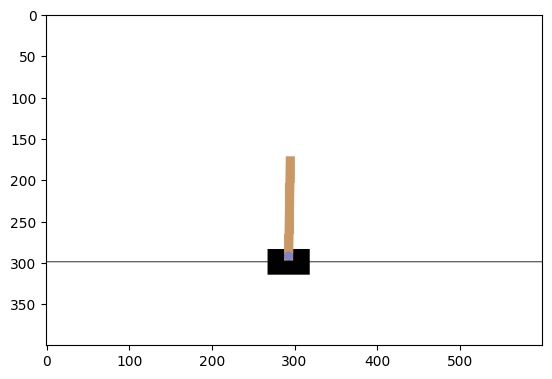

In [3]:
from matplotlib import pyplot as plt

%matplotlib inline


#打印游戏
def show():
    plt.imshow(env.render())
    plt.show()


show()

In [4]:
import torch

#定义模型
model = torch.nn.Sequential(
    torch.nn.Linear(4, 128),
    torch.nn.ReLU(),
    torch.nn.Linear(128, 2),
    torch.nn.Softmax(dim=1),
)

model_td = torch.nn.Sequential(
    torch.nn.Linear(4, 128),
    torch.nn.ReLU(),
    torch.nn.Linear(128, 1),
)

model(torch.randn(2, 4)), model_td(torch.randn(2, 4))

(tensor([[0.5126, 0.4874],
         [0.2233, 0.7767]], grad_fn=<SoftmaxBackward0>),
 tensor([[-0.1608],
         [-0.2853]], grad_fn=<AddmmBackward0>))

In [5]:
import random


#得到一个动作
def get_action(state):
    state = torch.FloatTensor(state).reshape(1, 4)
    #[1, 4] -> [1, 2]
    prob = model(state)

    #根据概率选择一个动作
    action = random.choices(range(2), weights=prob[0].tolist(), k=1)[0]

    return action


get_action([1, 2, 3, 4])

1

In [6]:
def get_data():
    states = []
    rewards = []
    actions = []
    next_states = []
    overs = []

    #初始化游戏
    state = env.reset()

    #玩到游戏结束为止
    over = False
    while not over:
        #根据当前状态得到一个动作
        action = get_action(state)

        #执行动作,得到反馈
        next_state, reward, over, _ = env.step(action)

        #记录数据样本
        states.append(state)
        rewards.append(reward)
        actions.append(action)
        next_states.append(next_state)
        overs.append(over)

        #更新游戏状态,开始下一个动作
        state = next_state

    #[b, 4]
    states = torch.FloatTensor(states).reshape(-1, 4)
    #[b, 1]
    rewards = torch.FloatTensor(rewards).reshape(-1, 1)
    #[b, 1]
    actions = torch.LongTensor(actions).reshape(-1, 1)
    #[b, 4]
    next_states = torch.FloatTensor(next_states).reshape(-1, 4)
    #[b, 1]
    overs = torch.LongTensor(overs).reshape(-1, 1)

    return states, rewards, actions, next_states, overs


get_data()

C:\Users\f'b'z\AppData\Local\Temp\ipykernel_30836\2726165283.py:31: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  states = torch.FloatTensor(states).reshape(-1, 4)


(tensor([[-0.0408, -0.0417,  0.0417,  0.0204],
         [-0.0416, -0.2374,  0.0421,  0.3260],
         [-0.0464, -0.4331,  0.0486,  0.6317],
         [-0.0550, -0.2386,  0.0613,  0.3547],
         [-0.0598, -0.0444,  0.0684,  0.0819],
         [-0.0607, -0.2405,  0.0700,  0.3954],
         [-0.0655, -0.4365,  0.0779,  0.7093],
         [-0.0742, -0.2426,  0.0921,  0.4421],
         [-0.0791, -0.0488,  0.1009,  0.1798],
         [-0.0801, -0.2453,  0.1045,  0.5026],
         [-0.0850, -0.4417,  0.1146,  0.8263],
         [-0.0938, -0.2483,  0.1311,  0.5717],
         [-0.0988, -0.4450,  0.1426,  0.9027],
         [-0.1077, -0.6417,  0.1606,  1.2365],
         [-0.1205, -0.4490,  0.1853,  0.9982],
         [-0.1295, -0.6460,  0.2053,  1.3429]]),
 tensor([[1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.]]),
 ten

In [7]:
from IPython import display


def test(play):
    #初始化游戏
    state = env.reset()

    #记录反馈值的和,这个值越大越好
    reward_sum = 0

    #玩到游戏结束为止
    over = False
    while not over:
        #根据当前状态得到一个动作
        action = get_action(state)

        #执行动作,得到反馈
        state, reward, over, _ = env.step(action)
        reward_sum += reward

        #打印动画
        if play and random.random() < 0.2:  #跳帧
            display.clear_output(wait=True)
            show()

    return reward_sum


test(play=False)

26.0

In [8]:
#优势函数
def get_advantages(deltas):
    advantages = []

    #反向遍历deltas
    s = 0.0
    for delta in deltas[::-1]:
        s = 0.98 * 0.95 * s + delta
        advantages.append(s)

    #逆序
    advantages.reverse()
    return advantages


get_advantages(range(5))

[8.090483997483998, 8.690100963999999, 8.260044, 6.724, 4.0]

In [9]:
def train():
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    optimizer_td = torch.optim.Adam(model_td.parameters(), lr=1e-2)
    loss_fn = torch.nn.MSELoss()

    #玩N局游戏,每局游戏训练M次
    for epoch in range(500):
        #玩一局游戏,得到数据
        #states -> [b, 4]
        #rewards -> [b, 1]
        #actions -> [b, 1]
        #next_states -> [b, 4]
        #overs -> [b, 1]
        states, rewards, actions, next_states, overs = get_data()

        #计算values和targets
        #[b, 4] -> [b, 1]
        values = model_td(states)

        #[b, 4] -> [b, 1]
        targets = model_td(next_states).detach()
        targets = targets * 0.98
        targets *= (1 - overs)
        targets += rewards

        #计算优势,这里的advantages有点像是策略梯度里的reward_sum
        #只是这里计算的不是reward,而是target和value的差
        #[b, 1]
        deltas = (targets - values).squeeze(dim=1).tolist()
        advantages = get_advantages(deltas)
        advantages = torch.FloatTensor(advantages).reshape(-1, 1)

        #取出每一步动作的概率
        #[b, 2] -> [b, 2] -> [b, 1]
        old_probs = model(states)
        old_probs = old_probs.gather(dim=1, index=actions)
        old_probs = old_probs.detach()

        #每批数据反复训练10次
        for _ in range(10):
            #重新计算每一步动作的概率
            #[b, 4] -> [b, 2]
            new_probs = model(states)
            #[b, 2] -> [b, 1]
            new_probs = new_probs.gather(dim=1, index=actions)
            new_probs = new_probs

            #求出概率的变化
            #[b, 1] - [b, 1] -> [b, 1]
            ratios = new_probs / old_probs

            #计算截断的和不截断的两份loss,取其中小的
            #[b, 1] * [b, 1] -> [b, 1]
            surr1 = ratios * advantages
            #[b, 1] * [b, 1] -> [b, 1]
            surr2 = torch.clamp(ratios, 0.8, 1.2) * advantages

            loss = -torch.min(surr1, surr2)
            loss = loss.mean()

            #重新计算value,并计算时序差分loss
            values = model_td(states)
            loss_td = loss_fn(values, targets)

            #更新参数
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            optimizer_td.zero_grad()
            loss_td.backward()
            optimizer_td.step()

        if epoch % 50 == 0:
            test_result = sum([test(play=False) for _ in range(10)]) / 10
            print(epoch, test_result)


train()

0 26.1
50 115.6
100 160.2
150 200.0
200 200.0
250 193.9
300 200.0
350 200.0
400 200.0
450 200.0


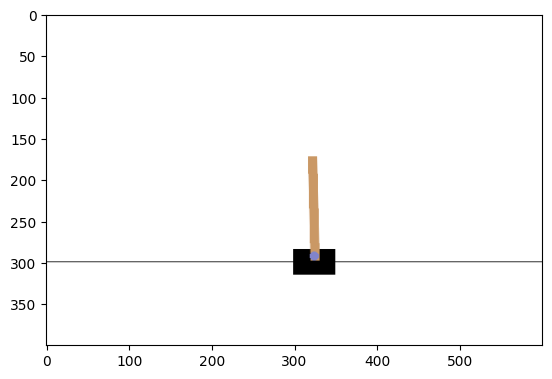

200.0

In [11]:
test(play=True)